In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:

import polars as pl

data = pl.read_csv(
    "trend_by_year_and_product.csv",
    encoding="utf8-lossy",
    ignore_errors=True
)

In [ ]:
data

In [ ]:
df = data.to_pandas()

df.head()

In [ ]:
df["Recall"] = (df["num_recalls"] > 0).astype(int)

df[["num_recalls","Recall"]].head()

In [2]:
from google.colab import files
uploaded = files.upload()

Saving trend_by_year_and_product.csv to trend_by_year_and_product.csv


In [3]:
import pandas as pd

df = pd.read_csv("trend_by_year_and_product.csv")

df.head()

,product_code,YEAR,num_complaints,num_recalls
0,OCE,2017,6,0
1,NBW,2015,60955,0
2,MQP,2015,258,0
3,MHY,2015,3053,1
4,NDN,2015,202,0


In [4]:
df.shape
df.head()

,product_code,YEAR,num_complaints,num_recalls
0,OCE,2017,6,0
1,NBW,2015,60955,0
2,MQP,2015,258,0
3,MHY,2015,3053,1
4,NDN,2015,202,0


In [5]:
df["Recall"] = (df["num_recalls"] > 0).astype(int)

In [6]:
X = df[["num_complaints"]]
y = df["Recall"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [10]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87      3450
           1       0.72      0.02      0.04      1062

    accuracy                           0.77      4512
   macro avg       0.74      0.51      0.45      4512
weighted avg       0.76      0.77      0.67      4512

ROC AUC: 0.7290761210731735


In [11]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [[8.48956264e-05]]
Intercept: [-1.20115437]


In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("trend_by_year_and_product.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())


# -----------------------------
# 2. BASIC CLEANING
# -----------------------------
df = df.copy()

# Make sure numeric columns are numeric
df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
df["num_complaints"] = pd.to_numeric(df["num_complaints"], errors="coerce")
df["num_recalls"] = pd.to_numeric(df["num_recalls"], errors="coerce")

# Drop bad rows
df = df.dropna(subset=["product_code", "YEAR", "num_complaints", "num_recalls"]).copy()

# Convert year to int
df["YEAR"] = df["YEAR"].astype(int)

# Sort by product and year
df = df.sort_values(["product_code", "YEAR"]).copy()


# -----------------------------
# 3. CREATE NEXT-YEAR TARGET
# -----------------------------
# Shift recalls upward within each product_code
df["num_recalls_next_year"] = df.groupby("product_code")["num_recalls"].shift(-1)

# Binary target: 1 if recalled next year, else 0
df["Recall_next_year"] = (df["num_recalls_next_year"] > 0).astype(int)

# Optional: drop the final year for each product if next year does not exist
df_model = df.dropna(subset=["num_recalls_next_year"]).copy()

print("\nSample after creating target:")
print(
    df_model[
        ["product_code", "YEAR", "num_complaints", "num_recalls", "num_recalls_next_year", "Recall_next_year"]
    ].head(10)
)

print("\nTarget distribution:")
print(df_model["Recall_next_year"].value_counts())


# -----------------------------
# 4. DEFINE FEATURES AND TARGET
# -----------------------------
X = df_model[["num_complaints"]]
y = df_model["Recall_next_year"]


# -----------------------------
# 5. TRAIN / TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# -----------------------------
# 6. TRAIN LOGISTIC REGRESSION
# -----------------------------
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)


# -----------------------------
# 7. PREDICT
# -----------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# -----------------------------
# 8. EVALUATE
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))


# -----------------------------
# 9. INTERPRET COEFFICIENT
# -----------------------------
coef = model.coef_[0][0]
intercept = model.intercept_[0]
odds_ratio = np.exp(coef)

print("\nCoefficient for num_complaints:", coef)
print("Intercept:", intercept)
print("Odds ratio for num_complaints:", odds_ratio)

if coef > 0:
    print("Interpretation: higher complaint volume is associated with higher odds of recall in the next year.")
else:
    print("Interpretation: higher complaint volume is associated with lower odds of recall in the next year.")


# -----------------------------
# 10. SAVE TEST RESULTS
# -----------------------------
test_results = X_test.copy()
test_results["actual_recall_next_year"] = y_test.values
test_results["predicted_recall_next_year"] = y_pred
test_results["predicted_probability"] = y_prob

print("\nTop predicted risks:")
print(test_results.sort_values("predicted_probability", ascending=False).head(20))

test_results.to_csv("next_year_recall_predictions.csv", index=False)
print("\nSaved: next_year_recall_predictions.csv")

Shape: (22558, 4)
Columns: ['product_code', 'YEAR', 'num_complaints', 'num_recalls']
  product_code  YEAR  num_complaints  num_recalls
0          OCE  2017               6            0
1          NBW  2015           60955            0
2          MQP  2015             258            0
3          MHY  2015            3053            1
4          NDN  2015             202            0

Sample after creating target:
      product_code  YEAR  num_complaints  num_recalls  num_recalls_next_year  \
16902          ---  2015              17            0                    0.0   
12760          ---  2016              30            0                    0.0   
5071           ---  2017               5            0                    0.0   
22089          ---  2018               3            0                    0.0   
3119           ---  2019              13            0                    0.0   
19302          ---  2020               4            0                    0.0   
6076           ---  2021

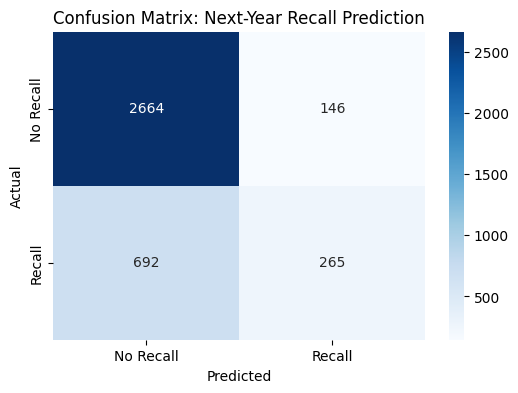

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Recall", "Recall"],
    yticklabels=["No Recall", "Recall"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Next-Year Recall Prediction")

plt.show()